In [26]:
import pandas as pd, numpy as np
import argparse
import pickle
import ast
import pandas as pd
from sklearn.utils import resample
import matplotlib.pyplot as plt
import re

# Utility functions

In [27]:
def pickle_to_res(path):
    with open(path, "rb") as f:
        raw_pickle = pickle.load(f)
    results = {}
    answer_prefix="Answer Choice "

    def extract_ans(ans_str, search_substring):
        # Split the string into lines
        lines = ans_str.split("\n")

        for line in lines:
            # Check if the line starts with the specified substring
            if line.startswith(search_substring):
                # If it does, add it to the list of extracted rows
                return line[len(search_substring) :].strip()
        return "ERROR"  # Answer not found

    for k, v in raw_pickle.items():
        if k != 'token_usage':  # Skip token_usage
            qns_idx = ast.literal_eval(k)
            for idx, qn_idx in enumerate(qns_idx):
                results[qn_idx] = extract_ans(
                    v[0], f"{answer_prefix}{idx+1}:"
                )  # We start with question 1
    
    return results



In [28]:
def extract_shots(experiment_files):
    """
    Extracts the shots values from a list of file paths, accounting for various patterns.
    
    Args:
        experiment_files (list): List of file paths containing shots information.
    
    Returns:
        list: Sorted list of unique shots values.
    """
    shots = set()  # Use a set to ensure uniqueness
    for file in experiment_files:
        # Extract the numeric patterns with flexible position
        match = re.search(r"(\d+)_(\d+)_(\d+)_(\d+)", file)
        if match:
            # Convert matched groups to integers
            numbers = [int(x) for x in match.groups()]
            # Sort numbers to extract the second largest
            numbers.sort()
            if len(numbers) > 1:
                shots.add(numbers[-2])
            else:
                shots.add(0)

    return sorted(shots)

In [29]:
# Count number of 56 and malignant in test_metadata.csv

test_df = pd.read_csv('C:/Users/sonne/Documents/Github/biasICL/ddi_test_metadata.csv', index_col=0)

print(f'Number of 56 and malignant: {len(test_df[(test_df.skin_tone == 56) & (test_df.malignant)])}')
print(f'Number of 12 and malignant: {len(test_df[(test_df.skin_tone == 12) & (test_df.malignant)])}')

print(f'Number of 56 and benign: {len(test_df[(test_df.skin_tone == 56) &  (~test_df.malignant)])}')
print(f'Number of 12 and benign: {len(test_df[(test_df.skin_tone == 12) & (~test_df.malignant)])}')

Number of 56 and malignant: 14
Number of 12 and malignant: 12
Number of 56 and benign: 38
Number of 12 and benign: 40


In [30]:
def res_to_vec(res):
    test_df = pd.read_csv('C:/Users/sonne/Documents/Github/biasICL/ddi_test_metadata.csv', index_col=0)
    num_errors = 0
    labels, preds, race = [], [], []
    for i in test_df.itertuples():
        fst = '12' if i.skin_tone == 12 else '56'
        if (i.Index not in res) or (res[i.Index].startswith("ERROR")):
            num_errors += 1

            print(i.Index, f"answer not found")
            continue

        pred_text = res[i.Index]
        ground_truth = "B" if i.malignant == True else "A"
        labels.append(ground_truth)
        preds.append(pred_text)
        race.append(fst)
        
    print(f"In total {num_errors} errors len = {len(labels)}")
    return labels,preds,race

In [31]:
def calculate_metrics_across_replicates(exp_lists):
    """
    Calculate metrics across technical replicates
    
    Parameters:
    exp_lists: List of 3 lists, where each inner list contains experiments for one technical replicate
               Corresponding experiments should be in the same order in each replicate list
    
    Returns:
    Dictionaries containing means and standard errors for bulk, FST 1/2, and FST 5/6 metrics
    """
    # Initialize data structures for each metric type
    bulk_metrics = {'mean': [], 'stderr': []}
    fst12_metrics = {'mean': [], 'stderr': []}
    fst56_metrics = {'mean': [], 'stderr': []}
    
    # Get number of experiments in each replicate
    n_experiments = len(exp_lists[0])
    
    # For each experiment position
    for exp_idx in range(n_experiments):
        # Storage for metrics from each replicate
        bulk_replicate_metrics = []
        fst12_replicate_metrics = []
        fst56_replicate_metrics = []
        
        # Process each replicate
        for replicate_list in exp_lists:
            exp = replicate_list[exp_idx]
            results = pickle_to_res(exp)
            labels, preds, race = res_to_vec(results)
            
            # Calculate bulk metrics
            accuracy, tpr, tnr, fscore = calculate_metrics(labels, preds)
            bulk_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore
            })
            
            # Calculate FST 1/2 metrics
            fst12_labels, fst12_preds = filter_by_race(labels, preds, race, '12')
            accuracy, tpr, tnr, fscore = calculate_metrics(fst12_labels, fst12_preds)
            fst12_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore
            })
            
            # Calculate FST 5/6 metrics
            fst56_labels, fst56_preds = filter_by_race(labels, preds, race, '56')
            accuracy, tpr, tnr, fscore = calculate_metrics(fst56_labels, fst56_preds)
            fst56_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore
            })
        
        # Calculate means and standard errors across replicates
        def calc_mean_stderr(replicate_data, metric):
            values = [rep[metric] for rep in replicate_data]
            return np.mean(values), np.std(values) / np.sqrt(len(values))
        
        # Process bulk metrics
        bulk_means = {}
        bulk_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore']:
            mean, stderr = calc_mean_stderr(bulk_replicate_metrics, metric)
            bulk_means[metric] = mean
            bulk_stderrs[metric] = stderr
        bulk_metrics['mean'].append(bulk_means)
        bulk_metrics['stderr'].append(bulk_stderrs)
        
        # Process FST 1/2 metrics
        fst12_means = {}
        fst12_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore']:
            mean, stderr = calc_mean_stderr(fst12_replicate_metrics, metric)
            fst12_means[metric] = mean
            fst12_stderrs[metric] = stderr
        fst12_metrics['mean'].append(fst12_means)
        fst12_metrics['stderr'].append(fst12_stderrs)
        
        # Process FST 5/6 metrics
        fst56_means = {}
        fst56_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore']:
            mean, stderr = calc_mean_stderr(fst56_replicate_metrics, metric)
            fst56_means[metric] = mean
            fst56_stderrs[metric] = stderr
        fst56_metrics['mean'].append(fst56_means)
        fst56_metrics['stderr'].append(fst56_stderrs)
    
    return bulk_metrics, fst12_metrics, fst56_metrics

def calculate_metrics(actual, predicted):
    TP = sum((a == 'B' and p == 'B') for a, p in zip(actual, predicted))
    TN = sum((a == 'A' and p == 'A') for a, p in zip(actual, predicted))
    FP = sum((a == 'A' and p == 'B') for a, p in zip(actual, predicted))
    FN = sum((a == 'B' and p == 'A') for a, p in zip(actual, predicted))
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    
    # Calculate F1 score
    if precision + recall > 0:
        f1_score = 2 * (precision * recall) / (precision + recall)
    else:
        f1_score = 0
    
    accuracy = (TP + TN) / len(actual)
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
    tnr = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    return accuracy, tpr, tnr, f1_score



def filter_by_race(actual, predicted, race, race_value):
    filtered_actual = [a for a, r in zip(actual, race) if r == race_value]
    filtered_predicted = [p for p, r in zip(predicted, race) if r == race_value]
    return filtered_actual, filtered_predicted

In [32]:
def plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, score_type, shots, use_error_bars=False):
    """
    Plot experiment metrics with confidence intervals
    
    Parameters:
    bulk_metrics, fst12_metrics, fst56_metrics: dictionaries containing means and standard deviations
    score_type: string indicating the type of score being plotted ('accuracy', 'tpr', or 'fscore')
    shots: list of integers representing the number of shots for each experiment
    use_error_bars: boolean indicating whether to use error bars instead of fill-between for uncertainty
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Use custom colors for the lines
    line_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
    
    # Extract means and standard deviations
    bulk_means = [m[score_type.lower()] for m in bulk_metrics['mean']]
    bulk_stds = [s[score_type.lower()] for s in bulk_metrics['stderr']]
    
    fst12_means = [m[score_type.lower()] for m in fst12_metrics['mean']]
    fst12_stds = [s[score_type.lower()] for s in fst12_metrics['stderr']]
    
    fst56_means = [m[score_type.lower()] for m in fst56_metrics['mean']]
    fst56_stds = [s[score_type.lower()] for s in fst56_metrics['stderr']]
    
    # Plot lines and confidence intervals
    if use_error_bars:
        ax1.errorbar(shots, bulk_means, yerr=bulk_stds, fmt='o-', 
                    color=line_colors[0], label=f'Aggregate {score_type}', 
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
        
        ax1.errorbar(shots, fst12_means, yerr=fst12_stds, fmt='s-',
                    color=line_colors[1], label=f'FST 1/2 {score_type}',
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
        
        ax1.errorbar(shots, fst56_means, yerr=fst56_stds, fmt='^-',
                    color=line_colors[2], label=f'FST 5/6 {score_type}',
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
    else:
        ax1.plot(shots, bulk_means, 'o-', color=line_colors[0], label=f'Aggregate {score_type}', linewidth=2)
        ax1.fill_between(shots, 
                        np.array(bulk_means) - np.array(bulk_stds),
                        np.array(bulk_means) + np.array(bulk_stds),
                        color=line_colors[0], alpha=0.2)
        
        ax1.plot(shots, fst12_means, 's-', color=line_colors[1], label=f'FST 1/2 {score_type}', linewidth=2)
        ax1.fill_between(shots,
                        np.array(fst12_means) - np.array(fst12_stds),
                        np.array(fst12_means) + np.array(fst12_stds),
                        color=line_colors[1], alpha=0.2)
        
        ax1.plot(shots, fst56_means, '^-', color=line_colors[2], label=f'FST 5/6 {score_type}', linewidth=2)
        ax1.fill_between(shots,
                        np.array(fst56_means) - np.array(fst56_stds),
                        np.array(fst56_means) + np.array(fst56_stds),
                        color=line_colors[2], alpha=0.2)
    
    ax1.set_xlabel('Number of Shots')
    ax1.set_ylabel(f'{score_type}')
    ax1.set_title(f'{score_type} by Number of Shots and Skin Type')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Plot bias with confidence intervals
    biases_mean = np.array(fst12_means) - np.array(fst56_means)
    biases_std = np.sqrt(np.array(fst12_stds)**2 + np.array(fst56_stds)**2)  # Error propagation
    print("biases_mean", biases_mean)
    if use_error_bars:
        ax2.errorbar(shots, biases_mean, yerr=biases_std, fmt='o-',
                    color='purple', label=f'Bias (FST 1/2 - FST 5/6 {score_type})',
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
    else:
        ax2.plot(shots, biases_mean, 'o-', color='purple', 
                label=f'Bias (FST 1/2 - FST 5/6 {score_type})', linewidth=2)
        ax2.fill_between(shots,
                        biases_mean - biases_std,
                        biases_mean + biases_std,
                        color='purple', alpha=0.2)
    
    ax2.set_xlabel('Number of Shots')
    ax2.set_ylabel('Bias')
    ax2.set_title('Bias by Number of Shots')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [33]:
def plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, title, use_error_bars=False):
    """
    Plot all experiment metrics (accuracy, TPR, F-score) in a single figure with multiple rows
    
    Parameters:
    bulk_metrics, fst12_metrics, fst56_metrics: dictionaries containing means and standard deviations/errors
    shots: list of integers representing the number of shots for each experiment
    title: string for the overall figure title
    use_error_bars: boolean indicating whether to use error bars instead of fill-between for uncertainty
    """
    # Create figure with 2 rows and 2 columns
    fig = plt.figure(figsize=(12, 9))
    
    # Create gridspec with adjusted spacing
    gs = fig.add_gridspec(2, 2, 
                         height_ratios=[1, 1], 
                         top=0.85,      # Space for title
                         bottom=0.1,    # Space for bottom labels
                         left=0.1,      # Space for left labels
                         right=0.9,     # Space for right margin
                         hspace=0.25,   # Increased vertical space between subplots
                         wspace=0.20)   # Space between columns
    
    axes = []
    for i in range(2):
        row = []
        for j in range(2):
            row.append(fig.add_subplot(gs[i, j]))
        axes.append(row)
    axes = np.array(axes)
    
    # Add title with padding
    fig.suptitle(title, fontsize=16, y=0.93)
    
    # Use custom colors for the lines
    line_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
    
    metrics = ['accuracy', 'fscore']
    
    for idx, score_type in enumerate(metrics):
        # Extract means and standard deviations for current metric
        bulk_means = [m[score_type] for m in bulk_metrics['mean']]
        bulk_stds = [s[score_type] for s in bulk_metrics['stderr']]
        
        fst12_means = [m[score_type] for m in fst12_metrics['mean']]
        fst12_stds = [s[score_type] for s in fst12_metrics['stderr']]
        
        fst56_means = [m[score_type] for m in fst56_metrics['mean']]
        fst56_stds = [s[score_type] for s in fst56_metrics['stderr']]
        
        # Left plot (metrics)
        if use_error_bars:
            axes[idx, 0].errorbar(shots, bulk_means, yerr=bulk_stds, fmt='o-', 
                                color=line_colors[0], label=f'Aggregate {score_type}', 
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
            
            axes[idx, 0].errorbar(shots, fst12_means, yerr=fst12_stds, fmt='s-',
                                color=line_colors[1], label=f'FST 1/2 {score_type}',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
            
            axes[idx, 0].errorbar(shots, fst56_means, yerr=fst56_stds, fmt='^-',
                                color=line_colors[2], label=f'FST 5/6 {score_type}',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
        else:
            axes[idx, 0].plot(shots, bulk_means, 'o-', color=line_colors[0], 
                            label=f'Aggregate {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots, 
                                    np.array(bulk_means) - np.array(bulk_stds),
                                    np.array(bulk_means) + np.array(bulk_stds),
                                    color=line_colors[0], alpha=0.2)
            
            axes[idx, 0].plot(shots, fst12_means, 's-', color=line_colors[1], 
                            label=f'FST 1/2 {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots,
                                    np.array(fst12_means) - np.array(fst12_stds),
                                    np.array(fst12_means) + np.array(fst12_stds),
                                    color=line_colors[1], alpha=0.2)
            
            axes[idx, 0].plot(shots, fst56_means, '^-', color=line_colors[2], 
                            label=f'FST 5/6 {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots,
                                    np.array(fst56_means) - np.array(fst56_stds),
                                    np.array(fst56_means) + np.array(fst56_stds),
                                    color=line_colors[2], alpha=0.2)
        
        axes[idx, 0].set_xlabel('Number of Shots')
        axes[idx, 0].set_ylabel(score_type.upper())
        axes[idx, 0].set_title(f'{score_type.upper()} by Number of Shots and Skin Type')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, linestyle='--', alpha=0.7)
        
        # Right plot (bias)
        biases_mean = np.array(fst12_means) - np.array(fst56_means)
        biases_std = np.sqrt(np.array(fst12_stds)**2 + np.array(fst56_stds)**2)  # Error propagation
        
        if use_error_bars:
            axes[idx, 1].errorbar(shots, biases_mean, yerr=biases_std, fmt='o-',
                                color='purple', label=f'Bias (FST 1/2 - FST 5/6 {score_type})',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
        else:
            axes[idx, 1].plot(shots, biases_mean, 'o-', color='purple', 
                            label=f'Bias (FST 1/2 - FST 5/6 {score_type})', linewidth=2)
            axes[idx, 1].fill_between(shots,
                                    biases_mean - biases_std,
                                    biases_mean + biases_std,
                                    color='purple', alpha=0.2)
        
        axes[idx, 1].set_xlabel('Number of Shots')
        axes[idx, 1].set_ylabel('Bias')
        axes[idx, 1].set_title(f'Bias in {score_type.upper()} by Number of Shots')
        axes[idx, 1].legend()
        axes[idx, 1].grid(True, linestyle='--', alpha=0.7)
    
    plt.show()

# fst 56 only

In [34]:
# Parameters for customization
base_path = "C:/Users/sonne/Downloads"
rep_folders = ["claude0104", "claude1217", "claude1131"]  # Subfolders for each replicate
model_name = "claude"  # Model name
numbers = [
    "0_0_0_0",
    "0_0_3_1",
    "0_0_9_3",
    "0_0_15_5",
    "0_0_21_7",
    "0_0_30_10",
]  # List of numerical settings

# Generate the experiment lists dynamically
exps_list = [
    [f"{base_path}/{folder}/ddi_{num}_{model_name}_50.pkl" for num in numbers]
    for folder in rep_folders
]

# Unpacking individual lists for convenience (optional)
exps_rep_1, exps_rep_2, exps_rep_3 = exps_list

# Output for verification
print("exps_rep_1:", exps_rep_1)
print("exps_rep_2:", exps_rep_2)
print("exps_rep_3:", exps_rep_3)


exps_rep_1: ['C:/Users/sonne/Downloads/claude0104/ddi_0_0_0_0_claude_50.pkl', 'C:/Users/sonne/Downloads/claude0104/ddi_0_0_3_1_claude_50.pkl', 'C:/Users/sonne/Downloads/claude0104/ddi_0_0_9_3_claude_50.pkl', 'C:/Users/sonne/Downloads/claude0104/ddi_0_0_15_5_claude_50.pkl', 'C:/Users/sonne/Downloads/claude0104/ddi_0_0_21_7_claude_50.pkl', 'C:/Users/sonne/Downloads/claude0104/ddi_0_0_30_10_claude_50.pkl']
exps_rep_2: ['C:/Users/sonne/Downloads/claude1217/ddi_0_0_0_0_claude_50.pkl', 'C:/Users/sonne/Downloads/claude1217/ddi_0_0_3_1_claude_50.pkl', 'C:/Users/sonne/Downloads/claude1217/ddi_0_0_9_3_claude_50.pkl', 'C:/Users/sonne/Downloads/claude1217/ddi_0_0_15_5_claude_50.pkl', 'C:/Users/sonne/Downloads/claude1217/ddi_0_0_21_7_claude_50.pkl', 'C:/Users/sonne/Downloads/claude1217/ddi_0_0_30_10_claude_50.pkl']
exps_rep_3: ['C:/Users/sonne/Downloads/claude1131/ddi_0_0_0_0_claude_50.pkl', 'C:/Users/sonne/Downloads/claude1131/ddi_0_0_3_1_claude_50.pkl', 'C:/Users/sonne/Downloads/claude1131/ddi_0_

In [35]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_metrics_across_replicates(exps_list)

In total 0 errors len = 104
204 answer not found
140 answer not found
373 answer not found
286 answer not found
In total 4 errors len = 100
14 answer not found
175 answer not found
152 answer not found
13 answer not found
249 answer not found
228 answer not found
244 answer not found
52 answer not found
90 answer not found
218 answer not found
136 answer not found
189 answer not found
186 answer not found
179 answer not found
66 answer not found
155 answer not found
0 answer not found
12 answer not found
33 answer not found
170 answer not found
236 answer not found
126 answer not found
240 answer not found
53 answer not found
125 answer not found
260 answer not found
316 answer not found
419 answer not found
426 answer not found
350 answer not found
47 answer not found
411 answer not found
407 answer not found
355 answer not found
378 answer not found
379 answer not found
39 answer not found
366 answer not found
434 answer not found
382 answer not found
347 answer not found
270 answer 

In [36]:
print((bulk_metrics), (fst12_metrics), (fst56_metrics))

{'mean': [{'accuracy': np.float64(0.4958072174738842), 'tpr': np.float64(0.6794871794871796), 'fscore': np.float64(0.4083430655438769)}, {'accuracy': np.float64(0.5572174738841406), 'tpr': np.float64(0.6025641025641025), 'fscore': np.float64(0.38705137227304715)}, {'accuracy': np.float64(0.668802465747158), 'tpr': np.float64(0.37606837606837606), 'fscore': np.float64(0.3632463064157054)}, {'accuracy': np.float64(0.642094017094017), 'tpr': np.float64(0.44871794871794873), 'fscore': np.float64(0.38103592314118623)}, {'accuracy': np.float64(0.6410256410256411), 'tpr': np.float64(0.4230769230769231), 'fscore': np.float64(0.36946773062925514)}, {'accuracy': np.float64(0.6314102564102564), 'tpr': np.float64(0.5128205128205128), 'fscore': np.float64(0.410136815920398)}], 'stderr': [{'accuracy': np.float64(0.018292255367446036), 'tpr': np.float64(0.10928813549183268), 'fscore': np.float64(0.02620591156156674)}, {'accuracy': np.float64(0.0550132246544422), 'tpr': np.float64(0.14542478228353467)

[0, 1, 3, 5, 7, 10]


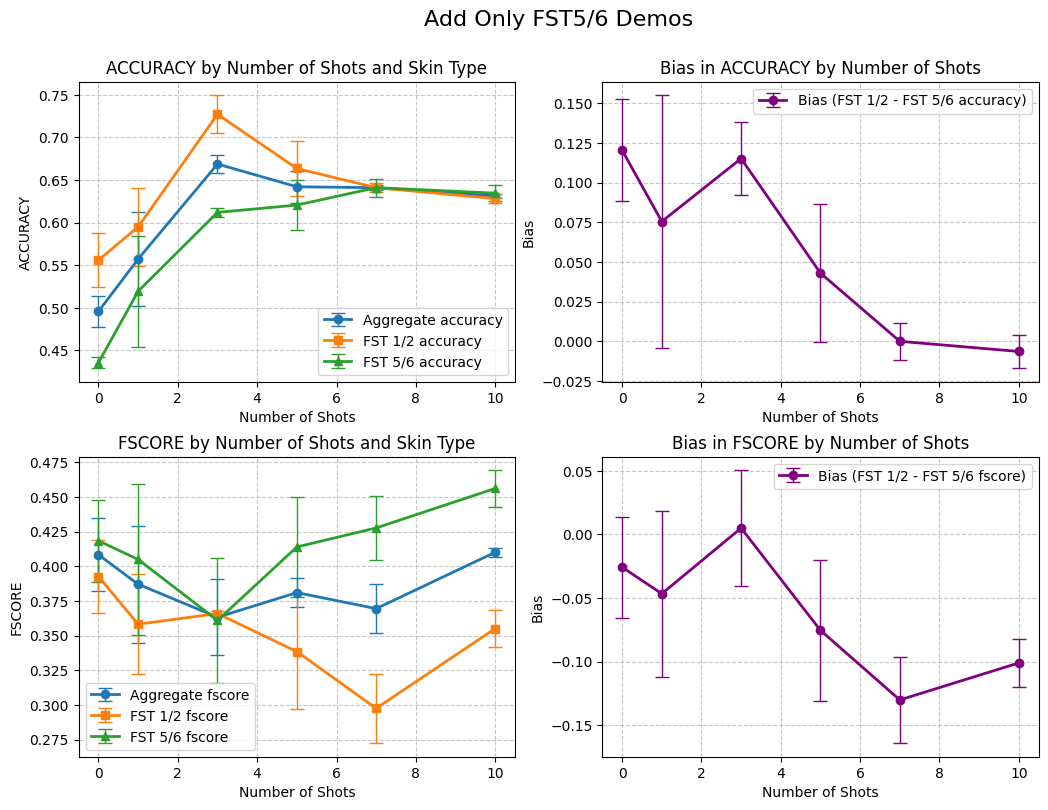

In [37]:
# Plot with confidence intervals
shots = extract_shots(numbers)
print(shots)
plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add Only FST5/6 Demos", 
                          use_error_bars=True)

# FST 12 only 

In [38]:
numbers = [
    "0_0_0_0",
    "3_1_0_0",
    "9_3_0_0",
    "15_5_0_0",
    "21_7_0_0",
    "30_10_0_0",
]  # List of numerical settings

# Generate the experiment lists dynamically
exps_list = [
    [f"{base_path}/{folder}/ddi_{num}_{model_name}_50.pkl" for num in numbers]
    for folder in rep_folders
]

In [39]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_metrics_across_replicates(exps_list)

In total 0 errors len = 104
204 answer not found
140 answer not found
373 answer not found
286 answer not found
In total 4 errors len = 100
14 answer not found
175 answer not found
152 answer not found
13 answer not found
249 answer not found
228 answer not found
244 answer not found
52 answer not found
90 answer not found
218 answer not found
136 answer not found
189 answer not found
186 answer not found
179 answer not found
66 answer not found
155 answer not found
0 answer not found
12 answer not found
33 answer not found
170 answer not found
236 answer not found
126 answer not found
240 answer not found
53 answer not found
125 answer not found
260 answer not found
316 answer not found
419 answer not found
426 answer not found
350 answer not found
47 answer not found
411 answer not found
407 answer not found
355 answer not found
378 answer not found
379 answer not found
39 answer not found
366 answer not found
434 answer not found
382 answer not found
347 answer not found
270 answer 

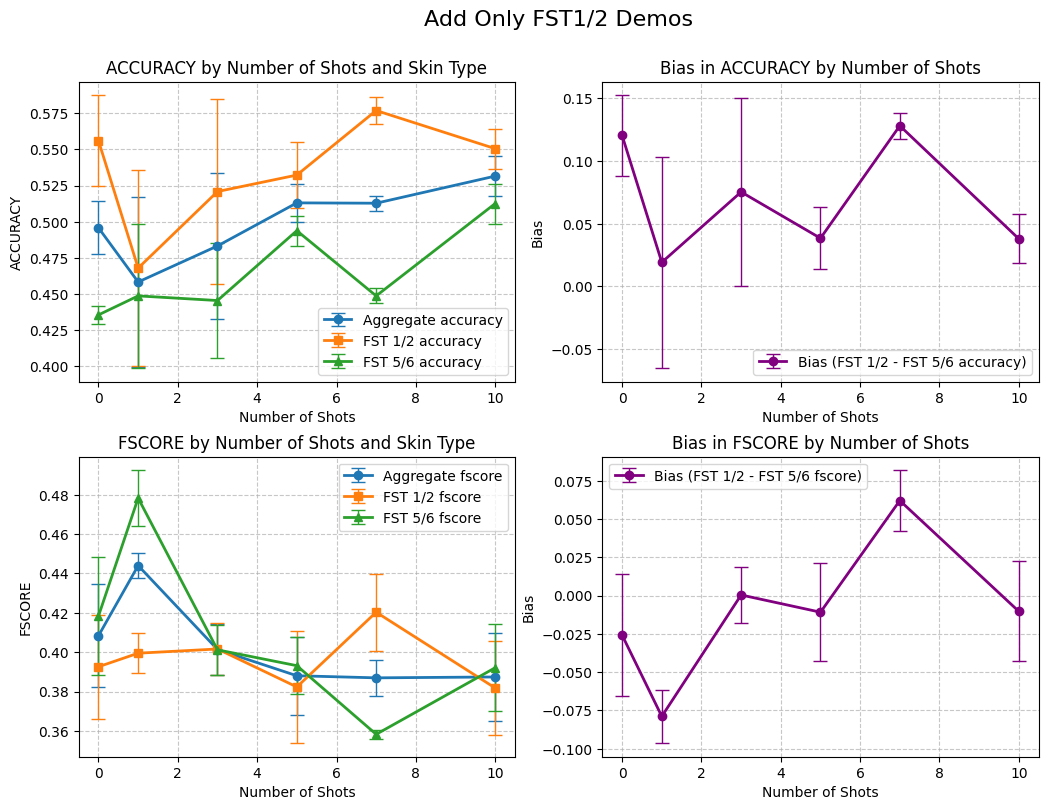

In [40]:
# Plot with confidence intervals
shots = extract_shots(numbers)
plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add Only FST1/2 Demos", 
                          use_error_bars=True)

# both fst12 and fst56

In [47]:
numbers = [
    "0_0_0_0",
    "3_1_3_1",
    "9_3_9_3",
    "15_5_15_5",
    # "21_7_21_7",
]  # List of numerical settings

# Generate the experiment lists dynamically
exps_list = [
    [f"{base_path}/{folder}/ddi_{num}_{model_name}_50.pkl" for num in numbers]
    for folder in rep_folders
]

In [48]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_metrics_across_replicates(exps_list)

In total 0 errors len = 104
204 answer not found
140 answer not found
373 answer not found
286 answer not found
In total 4 errors len = 100
14 answer not found
175 answer not found
152 answer not found
13 answer not found
249 answer not found
228 answer not found
244 answer not found
52 answer not found
90 answer not found
218 answer not found
136 answer not found
189 answer not found
186 answer not found
179 answer not found
66 answer not found
155 answer not found
0 answer not found
12 answer not found
33 answer not found
170 answer not found
236 answer not found
126 answer not found
240 answer not found
53 answer not found
125 answer not found
260 answer not found
316 answer not found
419 answer not found
426 answer not found
350 answer not found
47 answer not found
411 answer not found
407 answer not found
355 answer not found
378 answer not found
379 answer not found
39 answer not found
366 answer not found
434 answer not found
382 answer not found
347 answer not found
270 answer 

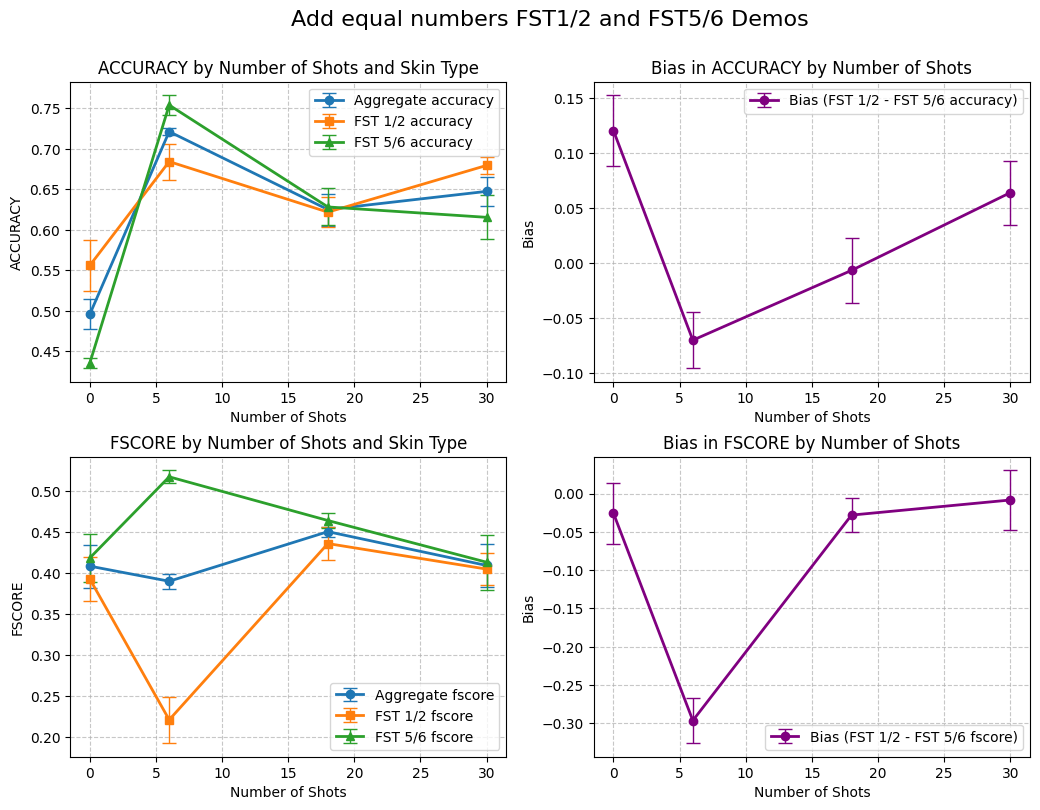

In [49]:
# Plot with confidence intervals
shots = extract_shots(numbers)
shots = [x * 2 for x in shots]
plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add equal numbers FST1/2 and FST5/6 Demos", 
                          use_error_bars=True)

In [44]:
print(bulk_metrics, fst12_metrics, fst56_metrics)

{'mean': [{'accuracy': np.float64(0.4958072174738842), 'tpr': np.float64(0.6794871794871796), 'fscore': np.float64(0.4083430655438769)}, {'accuracy': np.float64(0.7212624945675793), 'tpr': np.float64(0.3547008547008547), 'fscore': np.float64(0.3899459945008599)}, {'accuracy': np.float64(0.625), 'tpr': np.float64(0.6153846153846153), 'fscore': np.float64(0.4504227053140097)}, {'accuracy': np.float64(0.6474358974358975), 'tpr': np.float64(0.48717948717948717), 'fscore': np.float64(0.40919252711954984)}, {'accuracy': np.float64(0.75), 'tpr': np.float64(0.0), 'fscore': np.float64(0.0)}], 'stderr': [{'accuracy': np.float64(0.018292255367446036), 'tpr': np.float64(0.10928813549183268), 'fscore': np.float64(0.02620591156156674)}, {'accuracy': np.float64(0.004456130505706785), 'tpr': np.float64(0.012580855934939962), 'fscore': np.float64(0.008925115246356016)}, {'accuracy': np.float64(0.01975773718900315), 'tpr': np.float64(0.03626188621469475), 'fscore': np.float64(0.00619385876175997)}, {'ac